## 1. Setup

In [1]:
import sys
import random
import shutil
import warnings
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import auc, roc_curve, confusion_matrix, ConfusionMatrixDisplay

sys.path.insert(0, str(Path('..').resolve()))

from src.model import get_insightface_model, get_embedding, cosine_similarity
from src.database import EmbeddingDB
from src.authorization import identify
from src.metrics import compute_far_frr, compute_roc, eer, plot_roc, plot_far_frr_vs_threshold
from src.utils import list_images

warnings.filterwarnings('ignore')

SEED             = 44
DEFAULT_THRESH   = 0.4
TEST_DIR         = Path('../data/enrolled_test')

random.seed(SEED)
np.random.seed(SEED)

print('Loading model...')
app = get_insightface_model('buffalo_l', ctx_id=0)
db  = EmbeddingDB.from_file()

enrolled_users = set(db.get_all_users())
print(f'Enrolled users in DB : {len(enrolled_users)}')
print(f'Test directory       : {TEST_DIR.resolve()}')

Loading model...
Enrolled users in DB : 100
Test directory       : /home/drzewo/szt_mag/face/data/enrolled_test


## 2. Prepare multiple face per image data

Found 8042 source face crops.
Generating clean images...
  500/1000 images created in synth_clean
  1000/1000 images created in synth_clean
Generating hard images...
  500/5000 images created in synth_hard
  1000/5000 images created in synth_hard
  1500/5000 images created in synth_hard
  2000/5000 images created in synth_hard
  2500/5000 images created in synth_hard
  3000/5000 images created in synth_hard
  3500/5000 images created in synth_hard
  4000/5000 images created in synth_hard
  4500/5000 images created in synth_hard
  5000/5000 images created in synth_hard


<Figure size 640x480 with 0 Axes>

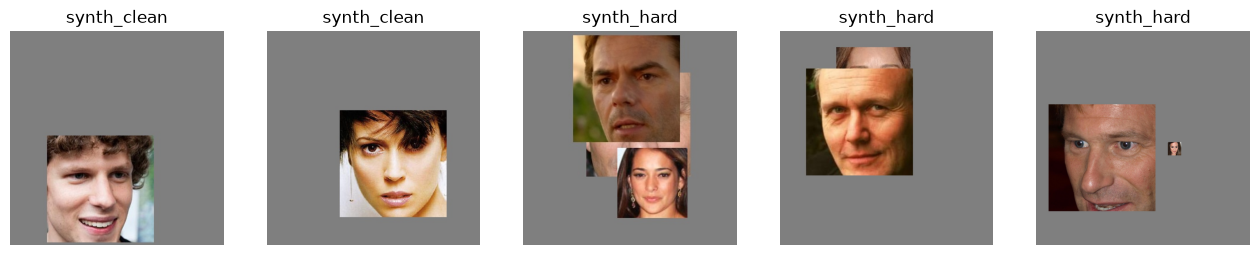

In [7]:
# Prepare synthetic clean / hard image datasets
DATA_ROOT          = Path('../data')
ENROLLED_DIR       = DATA_ROOT / 'enrolled'
ENROLLED_TEST      = DATA_ROOT / 'enrolled_test'
MULTIPLE_FACES_DIR = DATA_ROOT / 'multiple_faces'
SYNTH_CLEAN_DIR    = MULTIPLE_FACES_DIR / 'synth_clean'
SYNTH_HARD_DIR     = MULTIPLE_FACES_DIR / 'synth_hard'
NUM_CLEAN          = 1000
NUM_HARD           = 5000
SCALE_RANGE        = (0.8, 1.2)
HARD_FACE_COUNTS   = [2, 3]

face_paths = list_images(ENROLLED_DIR) + list_images(ENROLLED_TEST)
if len(face_paths) == 0:
    raise RuntimeError('No source faces found in enrolled directories.')

print(f'Found {len(face_paths)} source face crops.')

def make_background(face_size: tuple[int, int], fill_value: int = 127) -> np.ndarray:
    h, w = face_size
    return np.full((h * 2, w * 2, 3), fill_value, dtype=np.uint8)


def random_scale() -> float:
    return float(np.random.uniform(*SCALE_RANGE))


def scale_face(face: np.ndarray, scale: float) -> np.ndarray:
    h, w = face.shape[:2]
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    return cv2.resize(face, (new_w, new_h), interpolation=cv2.INTER_LINEAR)


def random_position(bg_shape: tuple[int, int, int], face_shape: tuple[int, int, int]) -> tuple[int, int]:
    bg_h, bg_w = bg_shape[:2]
    face_h, face_w = face_shape[:2]
    x = random.randint(0, bg_w - face_w)
    y = random.randint(0, bg_h - face_h)
    return x, y


def bbox_overlap(a: tuple[int, int, int, int], b: tuple[int, int, int, int]) -> float:
    x1 = max(a[0], b[0])
    y1 = max(a[1], b[1])
    x2 = min(a[2], b[2])
    y2 = min(a[3], b[3])
    if x2 <= x1 or y2 <= y1:
        return 0.0
    inter = (x2 - x1) * (y2 - y1)
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    return inter / area_a


def place_face(bg: np.ndarray, face: np.ndarray, existing_boxes: list[tuple[int, int, int, int]]) -> tuple[np.ndarray, tuple[int, int, int, int]]:
    max_attempts = 20
    for _ in range(max_attempts):
        x, y = random_position(bg.shape, face.shape)
        box = (x, y, x + face.shape[1], y + face.shape[0])
        if all(bbox_overlap(box, other) < 0.6 for other in existing_boxes):
            bg[y:y + face.shape[0], x:x + face.shape[1]] = face
            return bg, box
    x, y = random_position(bg.shape, face.shape)
    box = (x, y, x + face.shape[1], y + face.shape[0])
    bg[y:y + face.shape[0], x:x + face.shape[1]] = face
    return bg, box


def build_clean_image(src_path: Path, dst_path: Path) -> str:
    face = cv2.imread(str(src_path))
    if face is None:
        raise FileNotFoundError(src_path)
    face = scale_face(face, random_scale())
    bg = make_background(face.shape[:2])
    x, y = random_position(bg.shape, face.shape)
    bg[y:y + face.shape[0], x:x + face.shape[1]] = face
    cv2.imwrite(str(dst_path), bg, [cv2.IMWRITE_JPEG_QUALITY, 95])
    return src_path.parent.name


def build_hard_image(src_paths: list[Path], dst_path: Path) -> list[str]:
    num_faces = random.choice(HARD_FACE_COUNTS)
    user_groups = _group_paths_by_user(src_paths)
    if len(user_groups) < 2:
        raise RuntimeError('Not enough distinct users to build hard images.')

    chosen_users = random.sample(list(user_groups.keys()), min(num_faces, len(user_groups)))
    faces: list[np.ndarray] = []
    used_users: list[str] = []
    for user in chosen_users:
        user_faces = user_groups[user]
        if not user_faces:
            continue
        path = random.choice(user_faces)
        face = cv2.imread(str(path))
        if face is None:
            continue
        faces.append(scale_face(face, random_scale()))
        used_users.append(user)

    if len(faces) < 2:
        raise RuntimeError('Failed to load enough distinct source faces for hard image.')

    bg_w = 2 * max(face.shape[1] for face in faces)
    bg_h = 2 * max(face.shape[0] for face in faces)
    bg = np.full((bg_h, bg_w, 3), 127, dtype=np.uint8)
    boxes: list[tuple[int, int, int, int]] = []
    for face in faces:
        bg, box = place_face(bg, face, boxes)
        boxes.append(box)
    cv2.imwrite(str(dst_path), bg, [cv2.IMWRITE_JPEG_QUALITY, 95])
    return used_users


def _group_paths_by_user(src_paths: list[Path]) -> dict[str, list[Path]]:
    groups: dict[str, list[Path]] = {}
    for path in src_paths:
        groups.setdefault(path.parent.name, []).append(path)
    return groups


def build_clean_dataset(dst_dir: Path, count: int, src_paths: list[Path]) -> list[dict]:
    dst_dir.mkdir(parents=True, exist_ok=True)
    metadata: list[dict] = []
    for idx in range(count):
        dst_path = dst_dir / f'{idx:06d}.jpg'
        true_user = build_clean_image(random.choice(src_paths), dst_path)
        metadata.append({'path': dst_path, 'true_users': [true_user]})
        if (idx + 1) % 500 == 0 or idx == count - 1:
            print(f'  {idx + 1}/{count} images created in {dst_dir.name}')
    return metadata


def build_hard_dataset(dst_dir: Path, count: int, src_paths: list[Path]) -> list[dict]:
    dst_dir.mkdir(parents=True, exist_ok=True)
    metadata: list[dict] = []
    user_groups = _group_paths_by_user(src_paths)
    if len(user_groups) < 2:
        raise RuntimeError('Not enough distinct users to build hard images.')

    for idx in range(count):
        dst_path = dst_dir / f'{idx:06d}.jpg'
        chosen_users = build_hard_image(src_paths, dst_path)
        metadata.append({'path': dst_path, 'true_users': chosen_users})
        if (idx + 1) % 500 == 0 or idx == count - 1:
            print(f'  {idx + 1}/{count} images created in {dst_dir.name}')
    return metadata


print('Generating clean images...')
clean_meta = build_clean_dataset(SYNTH_CLEAN_DIR, NUM_CLEAN, face_paths)
print('Generating hard images...')
hard_meta = build_hard_dataset(SYNTH_HARD_DIR, NUM_HARD, face_paths)

# Quick sample preview
sample_paths = [m['path'] for m in clean_meta[:2]] + [m['path'] for m in hard_meta[:3]]
plt.tight_layout()

fig, axes = plt.subplots(1, len(sample_paths), figsize=(16, 5))    

for ax, path in zip(axes, sample_paths):
    ax.axis('off')
    ax.set_title(path.parent.name)
    img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)

## 3. Compute scores

In [8]:
# Authentication for generated imagesprint('Authenticating generated images...')



def evaluate_authentication(metadata: list[dict], label: str) -> pd.DataFrame:
    results: list[dict] = []
    for idx, entry in enumerate(metadata):
        if idx > 50:
            break
        img = cv2.imread(str(entry['path']))
        if img is None:
            results.append({
                'dataset': label,
                'image': str(entry['path'].name),
                'true_users': entry['true_users'],
                'identified_user': None,
                'identified_score': 0.0,
                'identified_correct': False,
                'verified_any': False,
            })
            continue

        probe = get_embedding(app, img)
        if probe is None:
            results.append({
                'dataset': label,
                'image': str(entry['path'].name),
                'true_users': entry['true_users'],
                'identified_user': None,
                'identified_score': 0.0,
                'identified_correct': False,
                'verified_any': False,
            })
            continue

        identified_user, identified_score = identify(img, app, db, threshold=DEFAULT_THRESH)
        identified_correct = identified_user in entry['true_users'] if identified_user else False
        true_scores = [db.query_user(user, probe) for user in entry['true_users']]
        verified_any = max(true_scores, default=0.0) >= DEFAULT_THRESH

        results.append({
            'dataset': label,
            'image': str(entry['path'].name),
            'true_users': entry['true_users'],
            'identified_user': identified_user,
            'identified_score': identified_score,
            'identified_correct': identified_correct,
            'verified_any': verified_any,
            'max_true_score': max(true_scores, default=0.0),
        })

        if (idx + 1) % 1000 == 0 or idx == len(metadata) - 1:
            print(f'  {label}: authenticated {idx + 1}/{len(metadata)} images')

    return pd.DataFrame(results)


clean_auth = evaluate_authentication(clean_meta, 'clean')
hard_auth = evaluate_authentication(hard_meta, 'hard')

summary = pd.DataFrame([
    {
        'dataset': 'clean',
        'count': len(clean_auth),
        'identification_accuracy': float(clean_auth['identified_correct'].mean()),
        'verification_pass_rate': float(clean_auth['verified_any'].mean()),
    },
    {
        'dataset': 'hard',
        'count': len(hard_auth),
        'identification_accuracy': float(hard_auth['identified_correct'].mean()),
        'verification_pass_rate': float(hard_auth['verified_any'].mean()),
    },
])

print('\nAuthentication summary:')
print(summary.to_string(index=False))

# Preview a few authentication rows
display(clean_auth.head(5))
display(hard_auth.head(5))



Authentication summary:
dataset  count  identification_accuracy  verification_pass_rate
  clean     51                 1.000000                1.000000
   hard     51                 0.980392                0.980392


,dataset,image,true_users,identified_user,identified_score,identified_correct,verified_any,max_true_score
0,clean,000000.jpg,[Jesse_Eisenberg],Jesse_Eisenberg,0.767350,True,True,0.767349
1,clean,000001.jpg,[Alyssa_Milano],Alyssa_Milano,0.648322,True,True,0.648321
2,clean,000002.jpg,[Jennifer_Aniston],Jennifer_Aniston,0.627099,True,True,0.627098
3,clean,000003.jpg,[Joan_Collins],Joan_Collins,0.793963,True,True,0.793963
4,clean,000004.jpg,[Ethan_Hawke],Ethan_Hawke,0.889624,True,True,0.889623


,dataset,image,true_users,identified_user,identified_score,identified_correct,verified_any,max_true_score
0,hard,000000.jpg,"[Chris_Kattan, Natalie_Martinez, Billy_Burke]",Billy_Burke,0.805208,True,True,0.805208
1,hard,000001.jpg,"[Barbara_Carrera, Anthony_Stewart_Head]",Anthony_Stewart_Head,0.799742,True,True,0.799742
2,hard,000002.jpg,"[Christina_Bennett_Lind, Aaron_Eckhart]",Aaron_Eckhart,0.765948,True,True,0.765948
3,hard,000003.jpg,"[Taylor_Atelian, Adrien_Brody, Chyler_Leigh]",NaN,0.309915,False,False,0.309915
4,hard,000004.jpg,"[Lori_Loughlin, Danny_Trejo, Anthony_Stewart_H...",Danny_Trejo,0.742248,True,True,0.742248
